In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('17-cardekho.csv')

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [6]:
df['seats'].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [8]:
df = df.drop('Unnamed: 0', axis=1)

In [9]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [10]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [11]:
df.drop_duplicates(keep='first', ignore_index=True, inplace=True)

In [12]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [13]:
df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [14]:
df.loc[df['seats'] == 0, "seats"] = 5

Genel kullanımı df.loc[satır_seçimi, sütun_seçimi] şeklindedir.

Sizin kodunuzun adım adım dökümü:

df.loc[df['seats'] == 0, "seats"] = 5

df.loc[ ... ]: "DataFrame'de (df) belirli bir konumu (loc) seç" komutunu verir.

df['seats'] == 0: Bu kısım satırları seçer.

DataFrame'deki 'seats' sütununa gider.

Bu sütundaki değeri 0 olan tüm satırları bulur. (Bu bir koşuldur).

,: Satır seçimini sütun seçiminden ayırır.

"seats": Bu kısım sütunu seçer.

"Yukarıdaki koşulu sağlayan (yani 'seats' değeri 0 olan) satırların sadece 'seats' sütununu istiyorum" der.

= 5: Bu da atama işlemidir.

Seçilen bu konuma (yani 'seats' sütununda 0 olan tüm hücrelere) yeni değer olarak 5 sayısını ata (yaz).

In [15]:
df['seats'].value_counts()

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [16]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326817,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.806464,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [17]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


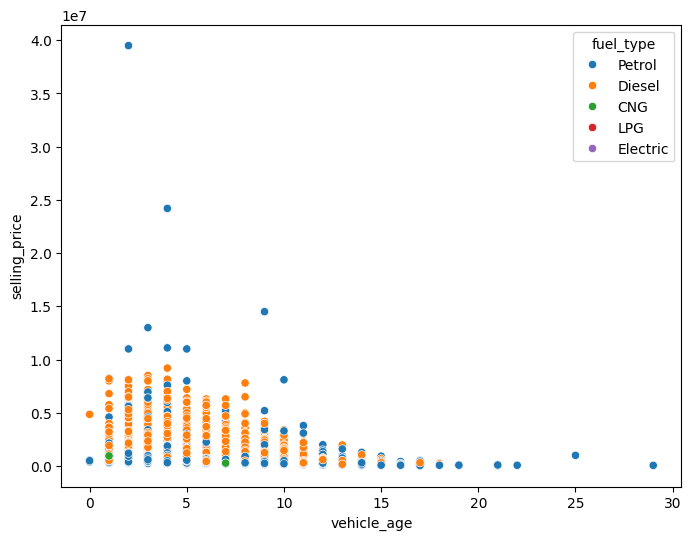

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x ="vehicle_age", y ="selling_price", hue="fuel_type")
plt.show()

In [19]:
df['selling_price'].max()

np.int64(39500000)

In [20]:
df = df[(df['selling_price'] < 15000000)] # 15 milyondan büyük outlier dataları df'den bu şekilde atabiliriz

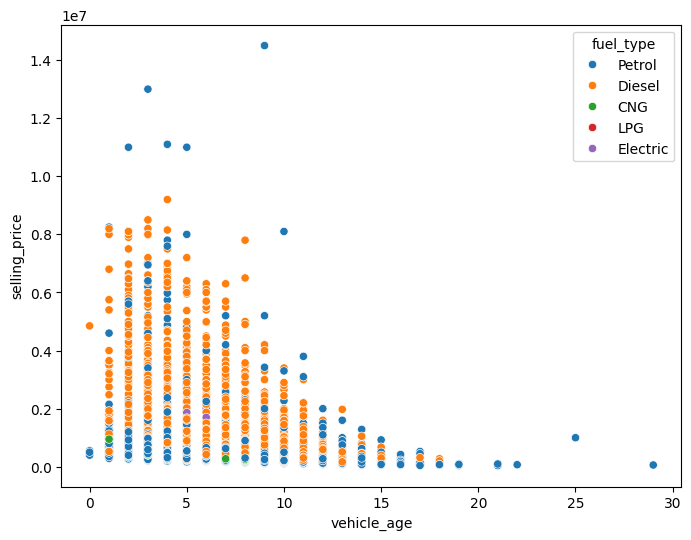

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x ="vehicle_age", y ="selling_price", hue="fuel_type")
plt.show()

In [22]:
df = df[(df['selling_price'] < 10000000)] # 10 milyon yapsak daha temiz bir data olur!

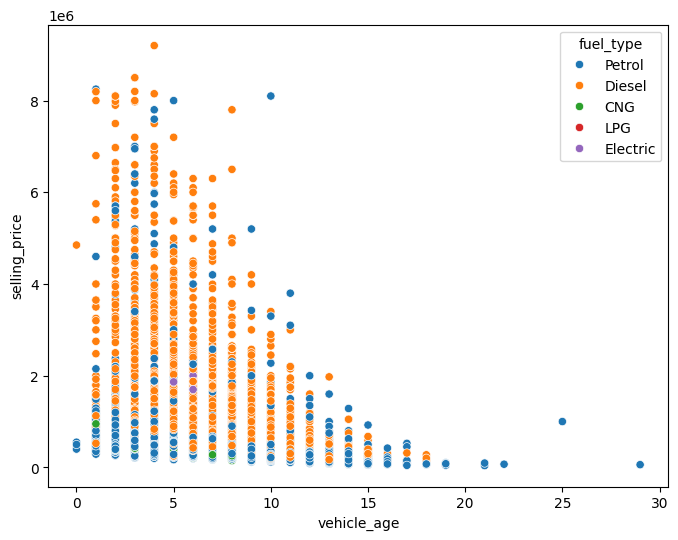

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x ="vehicle_age", y ="selling_price", hue="fuel_type")
plt.show()

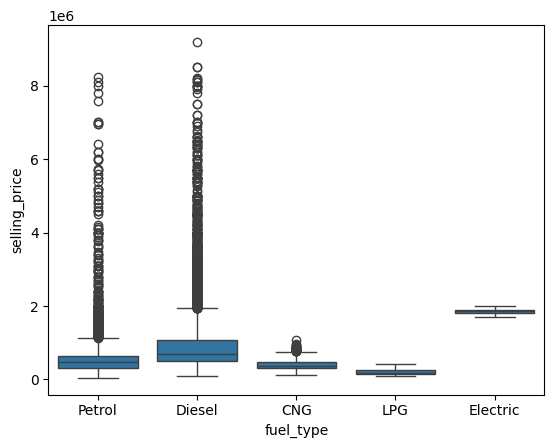

In [24]:
sns.boxplot(data=df, x = "fuel_type", y ="selling_price")
plt.show()

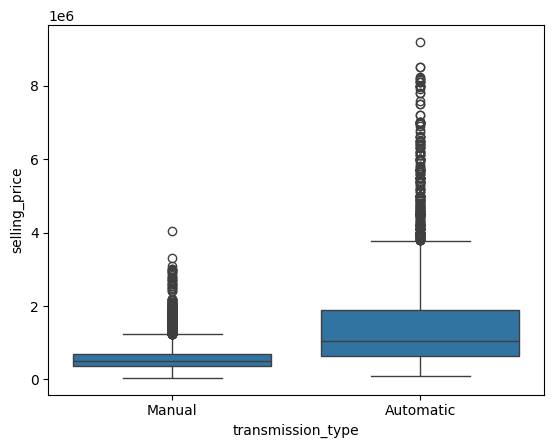

In [25]:
sns.boxplot(data=df, x = "transmission_type", y ="selling_price")
plt.show()

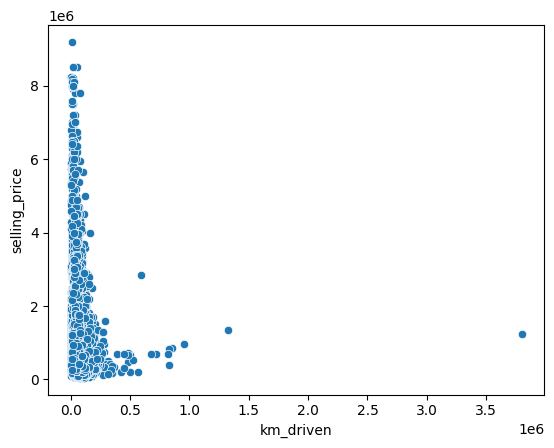

In [26]:
sns.scatterplot(data=df, x = "km_driven", y ="selling_price")
plt.show()

In [27]:
df = df[(df['km_driven'] < 1000000)]

In [28]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15235.000000,15235.000000,15235.00000,15235.000000,15235.000000,15235.000000,1.523500e+04
mean,6.041877,55329.175779,19.70325,1484.533246,100.420025,5.327141,7.668312e+05
std,3.016358,40673.179498,4.16268,515.028908,42.051568,0.806284,7.895932e+05
min,0.000000,100.000000,6.00000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,30000.000000,17.00000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,50000.000000,19.67000,1248.000000,88.500000,5.000000,5.570000e+05
75%,8.000000,70000.000000,22.70000,1582.000000,117.300000,5.000000,8.235000e+05
max,29.000000,950000.000000,33.54000,5998.000000,600.000000,9.000000,9.200000e+06


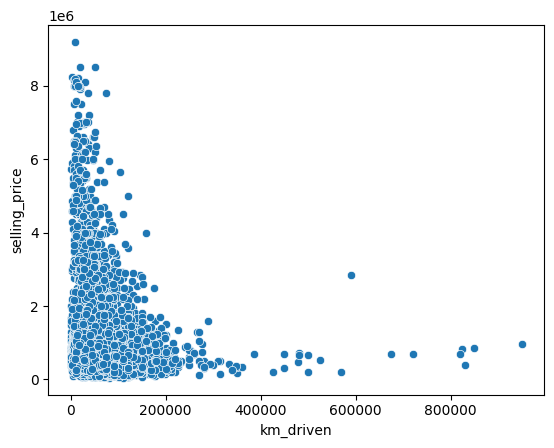

In [29]:
sns.scatterplot(data=df, x = "km_driven", y ="selling_price")
plt.show()

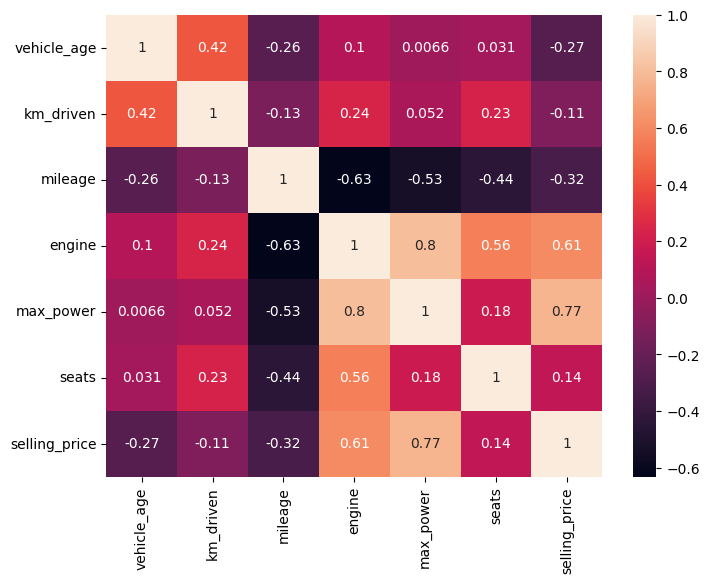

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [31]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

In [33]:
categorical_cols = df.select_dtypes("object").columns.to_list()  # Daha önce bu şekilde almamıştık. Ya manuel şekilde [] listeye kaydetmiştik. 
# ya da datatype == "O" olanları seç gibisinden şeyler yapmıştık. Bu kalıbı bilmek önemli ***

In [34]:
categorical_cols

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [35]:
unique_values = df[categorical_cols].nunique()

In [36]:
unique_values

car_name             119
brand                 30
model                118
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [37]:
# seller_type, fuel_type, transmission_type -> one hot encoding
# car_name, brand, model -> frequency encoding (kategorik değerler olduğu için modlarını alabiliriz)

In [38]:
onehot_columns = ['seller_type', 'fuel_type', 'transmission_type']
freq_columns = ['car_name', 'brand', 'model']

In [39]:
for col in freq_columns:
    freq = X_train[col].value_counts() / len(X_train)

    X_train[col + '_freq'] = X_train[col].map(freq) # örn-> col + '_freq': 'brand_freq' adında yeni bir sütun oluşturur gibi
    X_test[col + '_freq'] = X_test[col].map(freq) # X_train[col].map(freq): Orijinal 'brand' sütunundaki her bir değere bakar, 
                                                  # bu değeri freq haritasında arar ve karşılığını yeni sütuna yazar.
    mean_freq = freq.mean()
    X_test[col + '_freq'] = X_test[col + '_freq'].fillna(mean_freq) # test verisindeki boşlukları doldururuz.

# Özetle Ne Yaptık?

Bu kod bloğu, kategorik (metin) sütunları (araba markası, modeli vb.) sayısal değerlere dönüştürdü.

Bunu yaparken, her bir kategorinin eğitim verisinde ne kadar "popüler" (sık) olduğunu hesapladı ve bu popülerlik oranını o kategorinin yeni sayısal değeri olarak atadı.

Test setinde karşısına çıkan ve daha önce hiç görmediği (eğitim setinde olmayan) bir kategoriye ise "ortalama bir popülerlik" değeri atayarak modelin hata vermesini engelledi.

In [40]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
5902,Hyundai Creta,Hyundai,Creta,5,57000,Dealer,Diesel,Manual,19.67,1582,126.20,5,0.020742,0.193681,0.020742
14263,Maruti Alto,Maruti,Alto,3,25000,Individual,Petrol,Manual,24.70,796,47.30,5,0.050149,0.319797,0.050149
6954,Ford Ecosport,Ford,Ecosport,4,11448,Individual,Petrol,Manual,17.00,1497,121.36,5,0.024330,0.051287,0.024330
7077,Honda City,Honda,City,5,34000,Dealer,Diesel,Manual,25.10,1498,98.60,5,0.047873,0.095834,0.047873
14967,Maruti Celerio,Maruti,Celerio,5,29330,Dealer,Petrol,Automatic,23.10,998,67.04,5,0.016366,0.319797,0.016366


In [41]:
X_test.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
6756,Honda City,Honda,City,3,14000,Dealer,Petrol,Manual,17.40,1497,117.6,5,0.047873,0.095834,0.047873
9530,Hyundai Verna,Hyundai,Verna,6,43000,Dealer,Petrol,Manual,17.43,1396,105.5,5,0.030719,0.193681,0.030719
10758,Maruti Alto,Maruti,Alto,8,38000,Dealer,Petrol,Manual,22.74,796,47.3,5,0.050149,0.319797,0.050149
2147,Volkswagen Polo,Volkswagen,Polo,7,53000,Dealer,Petrol,Automatic,17.21,1197,103.6,5,0.023980,0.039996,0.023980
8425,Hyundai i10,Hyundai,i10,8,50000,Dealer,Petrol,Manual,20.36,1197,78.9,5,0.027131,0.193681,0.027131


In [42]:
X_train.drop(['car_name', 'brand', 'model'], axis=1, inplace=True)
X_test.drop(['car_name', 'brand', 'model'], axis=1,  inplace=True)

In [43]:
transformer = ColumnTransformer(
    transformers= [
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_columns)
    ], remainder= "passthrough"
)

# Görüntüdeki Kodun Adım Adım Açıklaması
## Şimdi kodunun her bir parçasının ne yaptığına bakalım. ##

Blok 1: ColumnTransformer'ı Tanımlama

Python

transformer = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_columns)
    ],
    remainder="passthrough"
)
Bu kodla Scikit-learn'e bir "iş planı" veriyorsun:

transformers=[...]: Bir liste içinde yapılacak işlemleri tanımlar.

("onehot", ...): Yaptığımız ilk işin adı "onehot" olsun (bu ismi biz uyduruyoruz).

OneHotEncoder(...): Bu iş için OneHotEncoder aracını kullan.

drop="first": "Dummy Variable Trap" tuzağına düşmemek için her kategorinin ilk sütununu sil (örn: fuel_type_Diesel ve fuel_type_Petrol yerine sadece fuel_type_Petrol yeterlidir. 0 ise Diesel, 1 ise Petrol demektir).

handle_unknown="ignore": Yukarıda açıkladığım gibi, test setinde karşına çıkan ama eğitimde görmediğin kategorileri (örn: LPG) görmezden gel, onlar için yeni sütun oluşturma.

onehot_columns: OneHotEncoder işlemini sadece onehot_columns listesindeki (['seller_type', 'fuel_type', 'transmission_type']) sütunlara uygula.

remainder="passthrough": "Geriye kalan" (remainder) diğer tüm sütunlara (vehicle_age, km_driven, mileage vs.) dokunma, onları olduğu gibi (passthrough) bırak.

In [44]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

transformer.fit_transform(X_train):

fit: X_train verisine bak, onehot_columns içindeki kategorileri (Petrol, Diesel vb.) ÖĞREN.

transform: Öğrendiğin bu kurallara göre X_train'i dönüştür.

transformer.transform(X_test):

Sadece transform!: Sakın X_test'e bakıp yeni bir kural ÖĞRENME (fit YOK). Sadece X_train'den öğrendiğin kuralları neyse, X_test'e de onu uygula.

In [45]:
encoded_columns = transformer.get_feature_names_out()

In [46]:
encoded_columns

array(['onehot__seller_type_Individual',
       'onehot__seller_type_Trustmark Dealer', 'onehot__fuel_type_Diesel',
       'onehot__fuel_type_Electric', 'onehot__fuel_type_LPG',
       'onehot__fuel_type_Petrol', 'onehot__transmission_type_Manual',
       'remainder__vehicle_age', 'remainder__km_driven',
       'remainder__mileage', 'remainder__engine', 'remainder__max_power',
       'remainder__seats', 'remainder__car_name_freq',
       'remainder__brand_freq', 'remainder__model_freq'], dtype=object)

In [47]:
X_train = pd.DataFrame(X_train, columns=encoded_columns)
X_test = pd.DataFrame(X_test, columns=encoded_columns)

In [48]:
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,57000.0,19.67,1582.0,126.20,5.0,0.020742,0.193681,0.020742
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,25000.0,24.70,796.0,47.30,5.0,0.050149,0.319797,0.050149
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,11448.0,17.00,1497.0,121.36,5.0,0.024330,0.051287,0.024330
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,34000.0,25.10,1498.0,98.60,5.0,0.047873,0.095834,0.047873
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,29330.0,23.10,998.0,67.04,5.0,0.016366,0.319797,0.016366


In [49]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        11426 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  11426 non-null  float64
 2   onehot__fuel_type_Diesel              11426 non-null  float64
 3   onehot__fuel_type_Electric            11426 non-null  float64
 4   onehot__fuel_type_LPG                 11426 non-null  float64
 5   onehot__fuel_type_Petrol              11426 non-null  float64
 6   onehot__transmission_type_Manual      11426 non-null  float64
 7   remainder__vehicle_age                11426 non-null  float64
 8   remainder__km_driven                  11426 non-null  float64
 9   remainder__mileage                    11426 non-null  float64
 10  remainder__engine                     11426 non-null  float64
 11  remainder__max_

# Özetle:

ColumnTransformer ile bir "dönüşüm planı" yaptın (One-Hot yap, geri kalana dokunma).

Bu planı X_train'de eğittin (fit) ve her iki veri setini de dönüştürdün (transform).

Dönüşüm sonucu verilerin DataFrame yapısı bozuldu, Numpy array'ine dönüştü.

get_feature_names_out() ile yeni oluşan sütunların isimlerini öğrendin.

Bu isimleri ve Numpy array'lerini kullanarak pd.DataFrame ile her şeyi tekrar anlamlı bir tablo haline getirdin.

In [50]:
model = AdaBoostRegressor()
model.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [51]:
y_pred = model.predict(X_test)

In [52]:
print("R2 SCORE:: ", r2_score(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))

R2 SCORE::  0.7016699643337787
MAE:  326857.2439371626
MSE:  170313721921.78906


In [53]:
params = {
    "n_estimators": [50,80,100,120],
    "learning_rate": [0.001, 0.01, 0.1, 1.0, 2.0],
    "loss": ["linear", "square", "exponential"]
}

In [54]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(), param_distributions=params, scoring='r2', cv=5, n_jobs=-1)

In [55]:
rcv.fit(X_train,y_train)

,estimator,AdaBoostRegressor()
,param_distributions,"{'learning_rate': [0.001, 0.01, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [56]:
rcv.best_params_

{'n_estimators': 120, 'loss': 'linear', 'learning_rate': 0.1}

In [57]:
y_pred = rcv.predict(X_test)

In [58]:
print("R2 SCORE:: ", r2_score(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))

R2 SCORE::  0.8049523296785628
MAE:  224278.13192728796
MSE:  111350821952.72011


In [59]:
# # if you want, you can tune the depth as well with manually initializing the tree

In [60]:
params = {
    "estimator__max_depth": [3,4,5], # isimlendirmeye dikkat et, estimator__max_depth -> __ iki çizgi var!!!!1
    "n_estimators": [50,80,100,120],
    "learning_rate": [0.001, 0.01, 0.1, 1.0, 2.0],
    "loss": ["linear", "square", "exponential"]
}

In [61]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(DecisionTreeRegressor()), param_distributions=params, scoring='r2', cv=5)

In [62]:
rcv.fit(X_train, y_train)

,estimator,AdaBoostRegre...eeRegressor())
,param_distributions,"{'estimator__max_depth': [3, 4, ...], 'learning_rate': [0.001, 0.01, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [63]:
rcv.best_params_

{'n_estimators': 120,
 'loss': 'square',
 'learning_rate': 0.1,
 'estimator__max_depth': 5}

In [64]:
y_pred = rcv.predict(X_test)

In [65]:
print("R2 SCORE:: ", r2_score(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))

R2 SCORE::  0.8839141580373475
MAE:  150248.3091887684
MSE:  66272280506.158
